# TIỀN XỬ LÝ DỮ LIỆU (DATA PREPROCESSING)
**Nhiệm vụ của phần này:**
1. **Kiểm tra dataset:** Đếm xem số lượng ảnh các loại quần áo có đều nhau không.
2. **Chia tập Train và Test:** Chia dữ liệu theo tỷ lệ chuẩn 60/20/20 và giữ đều tỉ lệ các lớp (Stratified Sampling).
3. **Data Augmentation:** Xoay/lật ảnh ngẫu nhiên (Data Augmentation) để AI học được nhiều góc độ thực tế.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms

# Khởi tạo danh sách tên các nhãn để trực quan hóa
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## Bước 1: Tải dữ liệu & Kiểm tra xem có bị "học lệch" không (Data Analysis)

* **Ý nghĩa:** Tải bộ ảnh quần áo `FashionMNIST` dùng PyTorch về và vẽ biểu đồ đếm xem mỗi loại (áo, quần, váy, giày...) có bao nhiêu ảnh.
* **Mục tiêu:** Đảm bảo dữ liệu cân bằng. Nếu một loại có quá nhiều ảnh (ví dụ 10,000 ảnh áo) mà loại khác quá ít (chỉ 100 ảnh váy), AI học xong sẽ bị "thiên vị" và luôn đoán bừa là áo.

In [2]:
# Tải dữ liệu thô (chỉ chuyển thành Tensor để phân tích)
raw_train = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
raw_test = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

In [3]:
img, label = raw_train[0]

Tổng số mẫu tập Train gốc: 60000 mẫu
Kích thước mỗi ảnh: torch.Size([1, 28, 28])


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14116\2318721045.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_labels, palette="viridis")


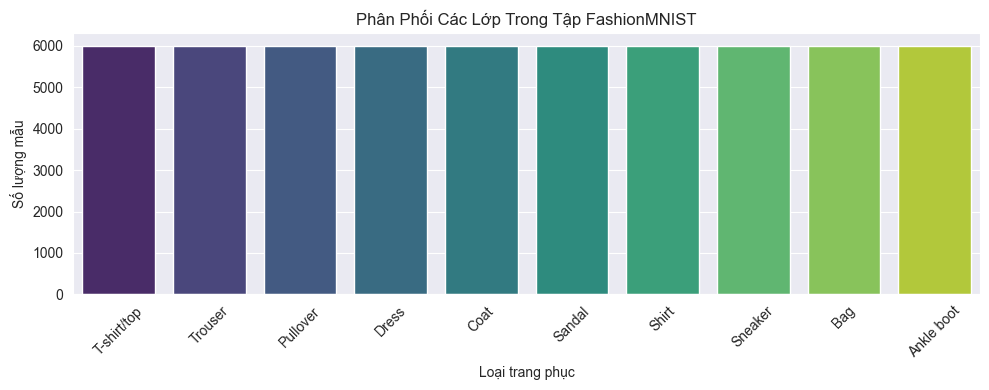

In [4]:

# Gộp nhãn để kiểm tra phân phối tổng thể
train_labels = raw_train.targets.numpy()
print(f"Tổng số mẫu tập Train gốc: {len(train_labels)} mẫu")
print(f"Kích thước mỗi ảnh: {raw_train[0][0].shape}")

# Vẽ biểu đồ phân phối tần suất các lớp
plt.figure(figsize=(10, 4))
sns.countplot(x=train_labels, palette="viridis")
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.title("Phân Phối Các Lớp Trong Tập FashionMNIST")
plt.xlabel("Loại trang phục")
plt.ylabel("Số lượng mẫu")
plt.tight_layout()
plt.show()

Tổng số mẫu tập Train gốc: 10000 mẫu
Kích thước mỗi ảnh: torch.Size([1, 28, 28])


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14116\1147419515.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=test_labels, palette="viridis")


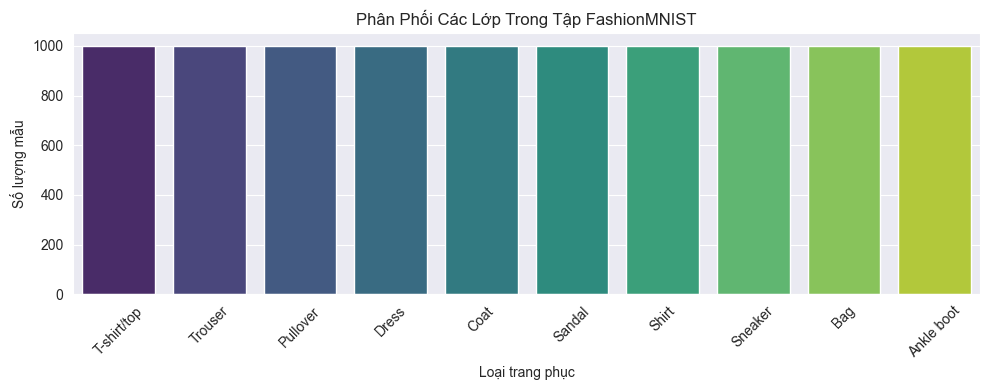

In [5]:

# Gộp nhãn để kiểm tra phân phối tổng thể
test_labels = raw_test.targets.numpy()
print(f"Tổng số mẫu tập Train gốc: {len(test_labels)} mẫu")
print(f"Kích thước mỗi ảnh: {raw_test[0][0].shape}")

# Vẽ biểu đồ phân phối tần suất các lớp
plt.figure(figsize=(10, 4))
sns.countplot(x=test_labels, palette="viridis")
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.title("Phân Phối Các Lớp Trong Tập FashionMNIST")
plt.xlabel("Loại trang phục")
plt.ylabel("Số lượng mẫu")
plt.tight_layout()
plt.show()

## Bước 2: Chia tập dữ liệu 60/20/20 (Stratified Sampling)

* **Vấn đề:** Bộ dữ liệu mặc định chỉ chia sẵn thành 2 tập (Train 60k và Test 10k). Chúng ta bị thiếu tập **Validation** (tập dùng để "nếm thử" xem AI học có bị học vẹt - Overfitting hay không).
* **Giải pháp:** 
 1. Gộp toàn bộ dữ liệu lại thành 70,000 ảnh để xáo trộn ngẫu nhiên.
  2. Cắt lần 1: Trích ra 20% làm tập **Test** .
  3. Cắt lần 2: Lấy phần còn lại chia thành tập **Train** (60%) và **Validation** (20%).
* **Từ khóa "Stratified":** Đảm bảo dù có chia nhỏ ra thì tỉ lệ các loại quần áo trong mỗi tập con vẫn bằng chằn chặn nhau, không bị lệch pha.

In [6]:
# Gộp toàn bộ dữ liệu 70,000 mẫu
full_dataset = ConcatDataset([raw_train, raw_test])
all_labels = np.concatenate([raw_train.targets.numpy(), raw_test.targets.numpy()])
all_indices = np.arange(len(full_dataset))

# Lần cắt 1: Trích ra đúng 20% làm tập Test (14,000 mẫu)
temp_indices, test_indices, y_temp, y_test = train_test_split(
    all_indices, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

# Lần cắt 2: Cắt tập Temp thành Train (60% ~ 42,000 mẫu) và Validation (20% ~ 14,000 mẫu)
train_indices, val_indices, _, _ = train_test_split(
    temp_indices, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print("--- Kết quả phân chia dữ liệu ---")
print(f"Số lượng mẫu tập Train (60%):      {len(train_indices)} mẫu")
print(f"Số lượng mẫu tập Validation (20%): {len(val_indices)} mẫu")
print(f"Số lượng mẫu tập Test (20%):       {len(test_indices)} mẫu")

--- Kết quả phân chia dữ liệu ---
Số lượng mẫu tập Train (60%):      42000 mẫu
Số lượng mẫu tập Validation (20%): 14000 mẫu
Số lượng mẫu tập Test (20%):       14000 mẫu


## Bước 3: Tăng cường hình ảnh (Data Augmentation) & Đóng gói dữ liệu (DataLoader)

* **Tăng cường dữ liệu (Data Augmentation):** Làm phong phú tập **Train** bằng cách xoay nhẹ ảnh hoặc lật ngang ngẫu nhiên. Giúp AI làm quen với nhiều góc chụp. *Lưu ý tinh tế:* Tuyệt đối không lật dọc ảnh quần áo vì thực tế không ai mặc đồ lộn ngược đầu xuống đất.
* **Tập Validation & Test:** Giữ nguyên ảnh gốc (chỉ thu nhỏ pixel về khoảng `[-1, 1]`) để chấm điểm AI khách quan.
* **DataLoader:** Đóng gói ảnh thành từng nhóm nhỏ (Batch size = 64) để nạp dần vào mạng CNN, giúp máy tính không bị "sập" do quá tải bộ nhớ.

In [9]:
# Định nghĩa các bộ lọc biến đổi dữ liệu
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

raw_train_aug = datasets.FashionMNIST(root="./data", train=True, download=True, transform=train_transform)
raw_test_aug = datasets.FashionMNIST(root="./data", train=False, download=True, transform=train_transform)
full_train_dataset = ConcatDataset([raw_train_aug, raw_test_aug])

raw_train_eval = datasets.FashionMNIST(root="./data", train=True, download=True, transform=eval_transform)
raw_test_eval = datasets.FashionMNIST(root="./data", train=False, download=True, transform=eval_transform)
full_eval_dataset = ConcatDataset([raw_train_eval, raw_test_eval])

# Bọc các tập dữ liệu đã chia bằng các phép biến đổi tương ứng
# Dùng các index (0-69999) để trích xuất từ tập full (70k ảnh)
train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_eval_dataset, val_indices)
test_dataset = Subset(full_eval_dataset, test_indices)

# Khởi tạo DataLoader sẵn sàng nạp vào mạng CNN để huấn luyện
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("--- HOÀN TẤT TIỀN XỬ LÝ DỮ LIỆU SẴN SÀNG CHO VÒNG LẶP HUẤN LUYỆN ---")

--- HOÀN TẤT TIỀN XỬ LÝ DỮ LIỆU SẴN SÀNG CHO VÒNG LẶP HUẤN LUYỆN ---


# PHẦN II: XÂY DỰNG VÀ SO SÁNH MODEL CNN 2D VÀ CNN 1D
**Nhiệm vụ của phần này:**
1. **Triển khai model CNN 2D:** Theo đúng cấu trúc yêu cầu từ đề bài.
2. **Thiết kế model CNN 1D tương ứng:** Làm phẳng ảnh và xử lý qua Conv1D.
3. **Huấn luyện và Đánh giá:** Chạy huấn luyện cả 2 model trên tập dữ liệu FashionMNIST và so sánh Loss, Accuracy, thời gian huấn luyện và số lượng tham số.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

class CNN2D(nn.Module):
    def __init__(self):
        super(CNN2D, self).__init__()
        
        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )
        
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

# Khởi tạo model và in số lượng tham số
model_2d = CNN2D()
total_params_2d = sum(p.numel() for p in model_2d.parameters() if p.requires_grad)
print(model_2d)
print(f"Tổng số tham số trainable của CNN 2D: {total_params_2d:,}")

CNN2D(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start

In [11]:
class CNN2D_Simple(nn.Module):
    def __init__(self):
        super(CNN2D_Simple, self).__init__()
        
        # Block 1 (chỉ có 1 lớp Conv2d)
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Block 2 (chỉ có 1 lớp Conv2d)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )
        
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

# Khởi tạo model và in số lượng tham số
model_2d_simple = CNN2D_Simple()
total_params_2d_simple = sum(p.numel() for p in model_2d_simple.parameters() if p.requires_grad)
print(model_2d_simple)
print(f"Tổng số tham số trainable của CNN 2D Simple (2 lớp Conv): {total_params_2d_simple:,}")

CNN2D_Simple(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Tổng số tham số trainable của CNN 2D Simple (2 lớp Conv): 421,834


In [12]:
class CNN1D(nn.Module):
    def __init__(self):
        super(CNN1D, self).__init__()
        
        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 196, 128), # 784 -> 392 (maxpool 1) -> 196 (maxpool 2)
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )
        
    def forward(self, x):
        # Biến đổi x từ (B, 1, 28, 28) thành (B, 1, 784) để xử lý dạng 1D sequence
        x = x.view(x.size(0), 1, -1)
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

model_1d = CNN1D()
total_params_1d = sum(p.numel() for p in model_1d.parameters() if p.requires_grad)
print(model_1d)
print(f"Tổng số tham số trainable của CNN 1D: {total_params_1d:,}")

CNN1D(
  (block1): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    

In [13]:
import time

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    val_loss = running_loss / total
    val_acc = correct / total
    return val_loss, val_acc

def fit_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on device: {device}")
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    start_time = time.time()
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")
              
    total_time = time.time() - start_time
    print(f"Hoàn thành huấn luyện trong {total_time:.2f}s\n")
    return history, total_time

In [14]:
print("--- HUẤN LUYỆN MODEL CNN 2D ---")
model_2d = CNN2D()
history_2d, time_2d = fit_model(model_2d, train_loader, valid_loader, epochs=10, lr=0.001)

# Đánh giá trên tập Test
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_loss_2d, test_acc_2d = evaluate(model_2d.to(device), test_loader, nn.CrossEntropyLoss(), device)
print(f"=> CNN 2D Test Loss: {test_loss_2d:.4f}, Test Accuracy: {test_acc_2d*100:.2f}%")

--- HUẤN LUYỆN MODEL CNN 2D ---
Training on device: cuda
Epoch [1/10] - Train Loss: 0.6277, Train Acc: 77.44% | Val Loss: 0.3760, Val Acc: 85.56%
Epoch [2/10] - Train Loss: 0.4345, Train Acc: 84.41% | Val Loss: 0.2887, Val Acc: 89.07%
Epoch [3/10] - Train Loss: 0.3835, Train Acc: 86.50% | Val Loss: 0.2759, Val Acc: 90.13%
Epoch [4/10] - Train Loss: 0.3589, Train Acc: 87.43% | Val Loss: 0.2551, Val Acc: 90.59%
Epoch [5/10] - Train Loss: 0.3364, Train Acc: 87.95% | Val Loss: 0.2348, Val Acc: 91.41%
Epoch [6/10] - Train Loss: 0.3181, Train Acc: 88.73% | Val Loss: 0.2522, Val Acc: 90.75%
Epoch [7/10] - Train Loss: 0.3059, Train Acc: 89.01% | Val Loss: 0.2443, Val Acc: 91.09%
Epoch [8/10] - Train Loss: 0.2941, Train Acc: 89.58% | Val Loss: 0.2373, Val Acc: 91.59%
Epoch [9/10] - Train Loss: 0.2857, Train Acc: 89.79% | Val Loss: 0.2202, Val Acc: 92.04%
Epoch [10/10] - Train Loss: 0.2784, Train Acc: 90.13% | Val Loss: 0.2226, Val Acc: 91.98%
Hoàn thành huấn luyện trong 181.30s

=> CNN 2D Test 

In [15]:
print("--- HUẤN LUYỆN MODEL CNN 2D SIMPLE (2 LỚP CONV) ---")
model_2d_simple = CNN2D_Simple()
history_2d_simple, time_2d_simple = fit_model(model_2d_simple, train_loader, valid_loader, epochs=10, lr=0.001)

# Đánh giá trên tập Test
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_loss_2d_simple, test_acc_2d_simple = evaluate(model_2d_simple.to(device), test_loader, nn.CrossEntropyLoss(), device)
print(f"=> CNN 2D Simple Test Loss: {test_loss_2d_simple:.4f}, Test Accuracy: {test_acc_2d_simple*100:.2f}%")

--- HUẤN LUYỆN MODEL CNN 2D SIMPLE (2 LỚP CONV) ---
Training on device: cuda
Epoch [1/10] - Train Loss: 0.6588, Train Acc: 76.41% | Val Loss: 0.3763, Val Acc: 85.84%
Epoch [2/10] - Train Loss: 0.4864, Train Acc: 82.43% | Val Loss: 0.3360, Val Acc: 87.20%
Epoch [3/10] - Train Loss: 0.4313, Train Acc: 84.36% | Val Loss: 0.3126, Val Acc: 88.17%
Epoch [4/10] - Train Loss: 0.4023, Train Acc: 85.46% | Val Loss: 0.2857, Val Acc: 89.22%
Epoch [5/10] - Train Loss: 0.3798, Train Acc: 86.18% | Val Loss: 0.2781, Val Acc: 89.44%
Epoch [6/10] - Train Loss: 0.3609, Train Acc: 87.11% | Val Loss: 0.2803, Val Acc: 89.32%
Epoch [7/10] - Train Loss: 0.3485, Train Acc: 87.52% | Val Loss: 0.2588, Val Acc: 90.47%
Epoch [8/10] - Train Loss: 0.3360, Train Acc: 88.06% | Val Loss: 0.2616, Val Acc: 90.12%
Epoch [9/10] - Train Loss: 0.3258, Train Acc: 88.34% | Val Loss: 0.2651, Val Acc: 90.59%
Epoch [10/10] - Train Loss: 0.3137, Train Acc: 88.70% | Val Loss: 0.2497, Val Acc: 90.67%
Hoàn thành huấn luyện trong 250.

In [16]:
print("--- HUẤN LUYỆN MODEL CNN 1D ---")
model_1d = CNN1D()
history_1d, time_1d = fit_model(model_1d, train_loader, valid_loader, epochs=10, lr=0.001)

# Đánh giá trên tập Test
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_loss_1d, test_acc_1d = evaluate(model_1d.to(device), test_loader, nn.CrossEntropyLoss(), device)
print(f"=> CNN 1D Test Loss: {test_loss_1d:.4f}, Test Accuracy: {test_acc_1d*100:.2f}%")

--- HUẤN LUYỆN MODEL CNN 1D ---
Training on device: cuda
Epoch [1/10] - Train Loss: 0.6838, Train Acc: 75.66% | Val Loss: 0.3889, Val Acc: 85.81%
Epoch [2/10] - Train Loss: 0.5035, Train Acc: 81.72% | Val Loss: 0.3400, Val Acc: 87.09%
Epoch [3/10] - Train Loss: 0.4530, Train Acc: 83.60% | Val Loss: 0.3018, Val Acc: 88.59%
Epoch [4/10] - Train Loss: 0.4175, Train Acc: 84.99% | Val Loss: 0.2953, Val Acc: 89.25%
Epoch [5/10] - Train Loss: 0.3920, Train Acc: 85.88% | Val Loss: 0.2969, Val Acc: 89.06%
Epoch [6/10] - Train Loss: 0.3750, Train Acc: 86.44% | Val Loss: 0.2693, Val Acc: 89.78%
Epoch [7/10] - Train Loss: 0.3574, Train Acc: 87.04% | Val Loss: 0.2610, Val Acc: 90.23%
Epoch [8/10] - Train Loss: 0.3485, Train Acc: 87.45% | Val Loss: 0.2539, Val Acc: 90.36%
Epoch [9/10] - Train Loss: 0.3300, Train Acc: 88.00% | Val Loss: 0.2482, Val Acc: 90.56%
Epoch [10/10] - Train Loss: 0.3255, Train Acc: 88.08% | Val Loss: 0.2466, Val Acc: 90.64%
Hoàn thành huấn luyện trong 253.96s

=> CNN 1D Test 

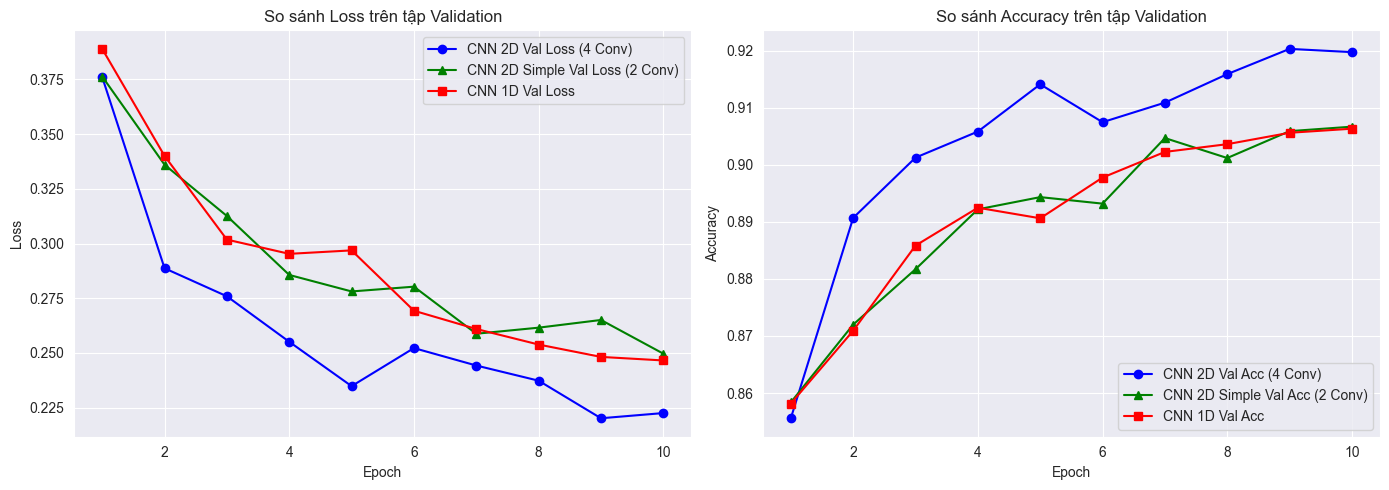

Thông số so sánh               | CNN 2D (4 Conv)    | CNN 2D (2 Conv)    | CNN 1D         
Trainable Parameters           | 468,202            | 421,834            | 1,629,226      
Thời gian train (10 epochs)    | 181.30s            | 250.03s            | 253.96s        
Validation Accuracy tốt nhất   | 92.04%             | 90.67%             | 90.64%         
Test Accuracy                  | 91.55%             | 90.50%             | 90.43%         


In [17]:
# So sánh và trực quan hóa kết quả cho cả 3 model
epochs_range = range(1, 11)

plt.figure(figsize=(14, 5))

# Biểu đồ Loss trên tập Validation
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_2d['val_loss'], 'b-o', label='CNN 2D Val Loss (4 Conv)')
plt.plot(epochs_range, history_2d_simple['val_loss'], 'g-^', label='CNN 2D Simple Val Loss (2 Conv)')
plt.plot(epochs_range, history_1d['val_loss'], 'r-s', label='CNN 1D Val Loss')
plt.title('So sánh Loss trên tập Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Biểu đồ Accuracy trên tập Validation
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_2d['val_acc'], 'b-o', label='CNN 2D Val Acc (4 Conv)')
plt.plot(epochs_range, history_2d_simple['val_acc'], 'g-^', label='CNN 2D Simple Val Acc (2 Conv)')
plt.plot(epochs_range, history_1d['val_acc'], 'r-s', label='CNN 1D Val Acc')
plt.title('So sánh Accuracy trên tập Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# In bảng so sánh
print("="*95)
print(f"{'Thông số so sánh':<30} | {'CNN 2D (4 Conv)':<18} | {'CNN 2D (2 Conv)':<18} | {'CNN 1D':<15}")
print("="*95)
print(f"{'Trainable Parameters':<30} | {total_params_2d:<18,} | {total_params_2d_simple:<18,} | {total_params_1d:<15,}")
print(f"{'Thời gian train (10 epochs)':<30} | {f'{time_2d:.2f}s':<18} | {f'{time_2d_simple:.2f}s':<18} | {f'{time_1d:.2f}s':<15}")
print(f"{'Validation Accuracy tốt nhất':<30} | {f'{max(history_2d["val_acc"])*100:.2f}%':<18} | {f'{max(history_2d_simple["val_acc"])*100:.2f}%':<18} | {f'{max(history_1d["val_acc"])*100:.2f}%':<15}")
print(f"{'Test Accuracy':<30} | {f'{test_acc_2d*100:.2f}%':<18} | {f'{test_acc_2d_simple*100:.2f}%':<18} | {f'{test_acc_1d*100:.2f}%':<15}")
print("="*95)